## Imports

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sys
import os
import datetime
import math
import scipy

from openradar.mmwave import dsp
from openradar.mmwave.dataloader.adc import DCA1000
from openradar.mmwave.dsp.range_processing import range_processing
from openradar.mmwave.dsp.doppler_processing import doppler_processing
from openradar.mmwave.dsp.utils import Window

## FFT Analysis
This section analyses and plots Range and Doppler FFTs

### Range FFT with GIF plot

In [21]:
DATA_PATH= r"../data\Rock_vibration\adc_data_2026-06-12_11-55-04_rock_layer_staticto100.npy"
DATA_PATH= DATA_PATH.replace("\\","/")

FILENAME=DATA_PATH.split("/")[-1].split(".")[0][29:]

save_dir = f"../Simulations/Radar/{FILENAME}"
os.makedirs(save_dir, exist_ok=True)

FILENAME=DATA_PATH.split("/")[-1].split(".")[0][29:]
print(FILENAME)
numFrames = 300
numADCSamples = 256
numTxAntennas = 3
numRxAntennas = 4
numLoopsPerFrame = 182
numChirpsPerFrame = numTxAntennas * numLoopsPerFrame

rock_layer_staticto100


In [ ]:
adc_data = np.load(DATA_PATH)
print("Raw data shape : " , adc_data.shape)

adc_data = np.apply_along_axis(DCA1000.organize, 1, adc_data,num_chirps=numChirpsPerFrame,num_rx=numRxAntennas, num_samples=numADCSamples)
print("Reshaped data shape: ", adc_data.shape)

print("Generating radar cubes...")
radar_cubes = np.array([range_processing(frame) for frame in adc_data])

print("Generating GIF...")
fig, ax = plt.subplots(figsize=(14, 5))
bins = np.arange(256)
global_max = np.max(np.abs(radar_cubes[:, 0, 0, :]))

magnitude_data_initial = np.abs(radar_cubes[0][0, 0, :])
line, = ax.plot(bins, magnitude_data_initial)

ax.set_xlabel("Range Bins")
ax.set_ylabel("Magnitude")
ax.grid(True)

ax.set_ylim(0, global_max * 1.1 + 1e-6)
def update(frame):
    magnitude_data = np.abs(radar_cubes[frame][0, 0, :])
    line.set_ydata(magnitude_data)
    ax.set_title(f"Range Profile (Frame {frame})")
    return [line]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(radar_cubes), 
    interval=50, 
    blit=False
)

target_folder = os.path.join(save_dir, "FFTs")
os.makedirs(target_folder, exist_ok=True)
ani.save(f"{save_dir}/FFTs/Range.gif", writer="pillow")

### Doppler FFT GIF Plot

In [ ]:
det_matrices = []
aoa_inputs = []

for cube in radar_cubes:
    det_matrix, aoa_input = doppler_processing(
        cube,
        num_tx_antennas=3, 
        clutter_removal_enabled=False,
        interleaved=True, 
        window_type_2d=Window.HANNING,
        accumulate=True     
    )
    det_matrices.append(det_matrix)
    aoa_inputs.append(aoa_input)

det_matrices = np.array(det_matrices)
aoa_inputs = np.array(aoa_inputs)

print("Generating doppler plot...")
rd_map = det_matrices[50]
rd_map_shifted = np.fft.fftshift(rd_map, axes=1)

global_vmin = np.min(det_matrices)
global_vmax = np.max(det_matrices)

fig, ax = plt.subplots(figsize=(10, 8))
initial_map = np.fft.fftshift(det_matrices[0], axes=1)

num_range_bins, num_doppler_bins = rd_map_shifted.shape
extent = [-num_doppler_bins // 2, num_doppler_bins // 2, 0, num_range_bins]

im = ax.imshow(
    initial_map, 
    aspect='auto', 
    origin='lower', 
    cmap='jet', 
    extent=extent,
    vmin=global_vmin, 
    vmax=global_vmax
)

ax.set_xlabel("Doppler Bins")
ax.set_ylabel("Range Bins")
cbar = fig.colorbar(im, label="Magnitude")

def update(frame):
    rd_map_shifted = np.fft.fftshift(det_matrices[frame], axes=1)
    im.set_array(rd_map_shifted)
    ax.set_title(f"Range-Doppler Heatmap (Frame {frame})")
    return [im]

ani = FuncAnimation(
    fig, 
    update, 
    frames=len(det_matrices), 
    interval=50, 
    blit=False  
)

ani.save(f"{save_dir}/FFTs/Doppler.gif", writer="pillow")

## Phase Analysis

### Cleaned phase plotting

In [13]:
def iterative_range_bins_detection(rangeResult, min_bin=10, max_bin=None):
    rangeResult = np.transpose(np.stack([rangeResult[0::3], rangeResult[1::3], rangeResult[2::3]], axis=1),axes=(1,2,0,3))
    range_result_absnormal_split=[]
    
    for i in range(numTxAntennas):
        for j in range(numRxAntennas):
            r_r=np.abs(rangeResult[i][j])
    
            r_r[:, :min_bin] = 0
            if max_bin is not None:
                r_r[:, max_bin:] = 0 
                
            min_val = np.min(r_r)
            max_val = np.max(r_r)
            
            if max_val == min_val: 
                r_r_normalise = np.zeros_like(r_r)
            else:
                r_r_normalise = (r_r - min_val) / (max_val - min_val) * (1000 - 0) + 0
                
            range_result_absnormal_split.append(r_r_normalise)
    
    range_abs_combined_nparray=np.zeros((numLoopsPerFrame,numADCSamples))
    for ele in range_result_absnormal_split:
        range_abs_combined_nparray+=ele
    range_abs_combined_nparray/=(numTxAntennas*numRxAntennas)
    
    range_abs_combined_nparray_collapsed=np.sum(range_abs_combined_nparray,axis=0)/numLoopsPerFrame
    peaks_min_intensity_threshold = np.argsort(range_abs_combined_nparray_collapsed)[::-1][:max_bin-min_bin]
    max_range_index=np.argmax(range_abs_combined_nparray_collapsed)
    
    return max_range_index, peaks_min_intensity_threshold, rangeResult

def get_phase(r, i):
    return np.angle(complex(r, i))

def unwrap(phase_cur_frame):
    i=1
    new_signal_phase = phase_cur_frame
    for k,ele in enumerate(new_signal_phase):
        if k==len(new_signal_phase)-1:
            continue
        if new_signal_phase[k+1] - new_signal_phase[k] > 1.5*np.pi:
            new_signal_phase[k+1:] = new_signal_phase[k+1:] - 2*np.pi*np.ones(len(new_signal_phase[k+1:]))
        if new_signal_phase[k+1] - new_signal_phase[k] < -1.5*np.pi:
            new_signal_phase[k+1:] = new_signal_phase[k+1:] + 2*np.pi*np.ones(len(new_signal_phase[k+1:]))
    return np.array(new_signal_phase)

def solve_equation(phase_cur_frame):
    phase_diff=[]
    for soham in range (1,len(phase_cur_frame)):
        phase_diff.append(phase_cur_frame[soham]-phase_cur_frame[soham-1])
    L=100
    r0=20
    roots_of_frame=[]
    for i,val in enumerate(phase_diff):
        c=(phase_diff[i]*0.001/3.14)/(3*(Tp+Tc))
        t=3*(i+1)*(Tp+Tc)
        c1=t*t
        c2=-2*L*t
        c3=L*L-c*c*t*t
        c4=2*L*c*c*t
        c5=-r0*r0*c*c
        coefficients=[c1, c2, c3, c4, c5]
        root=min(np.abs(np.roots(coefficients)))
        roots_of_frame.append(root)
    median_root=np.median(roots_of_frame)
    final_roots=[]
    for root in roots_of_frame:
        if root >0.9*median_root and root<1.1*median_root:
            final_roots.append(root)
    return np.mean(final_roots)

def get_velocity_antennawise(range_FFT_,peak):
    phase_per_antenna=[]
    vel_peak=[]
    for k in range(0,numLoopsPerFrame):
        r = range_FFT_[k][peak].real
        i = range_FFT_[k][peak].imag
        phase=get_phase(r,i)
        phase_per_antenna.append(phase)
    phase_cur_frame=phase_unwrapping(len(phase_per_antenna),phase_per_antenna)
    cur_vel=solve_equation(phase_cur_frame)
    return cur_vel

def get_phase_antennawise(range_FFT_, peak):
    phase_per_antenna = []
    for k in range(numLoopsPerFrame):
        r = range_FFT_[k][peak].real
        i = range_FFT_[k][peak].imag
        phase_per_antenna.append(get_phase(r, i))
    
    phase_cur_frame = np.unwrap(phase_per_antenna)
    phase_cur_frame -= np.mean(phase_cur_frame)   # <-- add this
    return phase_cur_frame

def get_averaged_phase(rangeResult, target_bin):
    best_snr = -np.inf
    best_phase = None
    for tx in range(numTxAntennas):
        for rx in range(numRxAntennas):
            signal = rangeResult[tx][rx][:, target_bin]
            snr = np.mean(np.abs(signal)**2)
            if snr > best_snr:
                best_snr = snr
                best_phase = np.unwrap(np.angle(signal))
    best_phase -= np.mean(best_phase)
    return best_phase

### 546 chirps phase plotting with frequency mapping

#### Data paths

In [51]:
'data/Rock_vibration/depth_10/adc_data_2026-06-20_18-07-57_depth_10cm_motor_pow_0.npy',
'data/Rock_vibration/depth_10/adc_data_2026-06-20_18-09-49_depth_10cm_motor_pow_25.npy',
'data/Rock_vibration/depth_10/adc_data_2026-06-20_18-11-19_depth_10cm_motor_pow_50.npy',
'data/Rock_vibration/depth_10/adc_data_2026-06-20_18-13-00_depth_10cm_motor_pow_75.npy',
'data/Rock_vibration/depth_10/adc_data_2026-06-20_18-15-52_depth_10cm_motor_pow_100.npy',
'data/Rock_vibration/depth_10/adc_data_2026-06-20_18-18-11_depth_10cm_motor_pow_0_100.npy',

# 'data/Rock_vibration/depth_5/adc_data_2026-06-20_17-53-47_depth_5cm_motor_pow_0.npy',
# 'data/Rock_vibration/depth_5/adc_data_2026-06-20_17-56-36_depth_5cm_motor_pow_25.npy',
# 'data/Rock_vibration/depth_5/adc_data_2026-06-20_17-58-16_depth_5cm_motor_pow_50.npy',
# 'data/Rock_vibration/depth_5/adc_data_2026-06-20_18-01-03_depth_5cm_motor_pow_75.npy',
# 'data/Rock_vibration/depth_5/adc_data_2026-06-20_18-03-48_depth_5cm_motor_pow_100.npy',


DATA_PATHS = [
'data\Rock_vibration\depth_15/adc_data_2026-06-20_18-20-59_depth_15cm_motor_pow_0.npy',
'data\Rock_vibration\depth_15/adc_data_2026-06-20_18-23-03_depth_15cm_motor_pow_25.npy',
'data\Rock_vibration\depth_15/adc_data_2026-06-20_18-24-55_depth_15cm_motor_pow_50.npy',
'data\Rock_vibration\depth_15/adc_data_2026-06-20_18-26-49_depth_15cm_motor_pow_75.npy',
'data/Rock_vibration/depth_10/adc_data_2026-06-20_18-15-52_depth_10cm_motor_pow_100.npy',
'data\Rock_vibration\depth_15/adc_data_2026-06-20_18-29-38_depth_15cm_motor_pow_100.npy',
]


numFrames = 600
numADCSamples = 256
numTxAntennas = 3
numRxAntennas = 4
numLoopsPerFrame = 182
numChirpsPerFrame = numTxAntennas * numLoopsPerFrame



#### Config

In [52]:
min_b = 5
max_b = 20

start_frame = 100
num_frames = 50

target_bins=[13,14,15,16,17]
# target_bins=[8,9,10,11,12]

FREQ = 77e9                 
C = 3e8                     
LAMBDA_M = C / FREQ         
DT = 72e-6                  


#### 546 CHIRPS

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from openradar.mmwave.dsp.utils import Window
import matplotlib.animation as animation
from scipy.fft import fft, fftfreq
from scipy.signal import butter, sosfiltfilt

def get_calibrated_1rx_phases(rangeResult, target_bins, rx_channel=0):
    frame_phases = {}
    for target_bin in target_bins:
        tx_data = rangeResult[:, rx_channel, :, target_bin]        
        tx1 = tx_data[0, :]
        tx2 = tx_data[1, :]
        tx3 = tx_data[2, :]
        offset_tx2 = np.angle(np.mean(tx2 * np.conj(tx1)))
        offset_tx3 = np.angle(np.mean(tx3 * np.conj(tx1)))
        tx2_calibrated = tx2 * np.exp(-1j * offset_tx2)
        tx3_calibrated = tx3 * np.exp(-1j * offset_tx3)
        calibrated_matrix = np.vstack((tx1, tx2_calibrated, tx3_calibrated))
        chronological_complex = calibrated_matrix.T.flatten()
        frame_phases[target_bin] = np.angle(chronological_complex)
    return frame_phases

def plot_continuous_phase_separate_chirps(absolute_phase_history, target_bins, start_frame, num_frames, save_dir="Phase_Plots"):
    target_folder = os.path.join(save_dir, "Absolute_phase_546")
    csv_folder = os.path.join(save_dir, "phase_CSV")
    
    os.makedirs(target_folder, exist_ok=True)
    os.makedirs(csv_folder, exist_ok=True)
    
    # 1. Export all requested bins to a single consolidated CSV
    csv_data = {f"Bin_{b}": absolute_phase_history[b] for b in target_bins}
    df = pd.DataFrame(csv_data)
    df.index.name = "Chirp_Index"
    
    csv_filename = f"Absolute_Phase_frames_{start_frame}_to_{start_frame+num_frames}.csv"
    df.to_csv(os.path.join(csv_folder, csv_filename))

    # 2. Generate and save the plots
    for target_bin in target_bins:
        plt.figure(figsize=(14, 6))
        phase_data = absolute_phase_history[target_bin]
        chirp_indices = np.arange(len(phase_data))
        
        plt.plot(chirp_indices, phase_data, label=f'Bin {target_bin}', alpha=0.9, linewidth=1.5, color='#1f77b4')
        plt.title(f"Unwrapped Phase - Bin {target_bin}\nFrames: {start_frame} to {start_frame + num_frames - 1}", fontsize=14, fontweight='bold')
        plt.xlabel("Chirp Index", fontsize=12)
        plt.ylabel("Phase Offset (Radians)", fontsize=12)
        plt.ylim(-1,1)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(loc='upper right')
        plt.tight_layout()
        
        file_path = os.path.join(target_folder, f"Absolute_Phase_Bin_{target_bin}_frames_{start_frame}_to_{start_frame+num_frames}.png")
        plt.savefig(file_path, dpi=300)
        plt.close()

def plot_wrapped_vs_unwrapped(wrapped_history, unwrapped_history, target_bins, save_dir="Phase_Plots"):
    target_folder = os.path.join(save_dir, "Wrapped_vs_Unwrapped")
    os.makedirs(target_folder, exist_ok=True)
    
    for target_bin in target_bins:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        wrapped_data = wrapped_history[target_bin]
        unwrapped_data = unwrapped_history[target_bin]
        chirps = np.arange(len(wrapped_data))

        ax1.plot(chirps, wrapped_data, color='#ff7f0e', linewidth=1.2)
        ax1.set_title(f"Raw Wrapped Phase (-π to π) - Bin {target_bin}", fontsize=12, fontweight='bold')
        ax1.set_ylabel("Phase (Rad)")
        ax1.grid(True, linestyle=':', alpha=0.7)

        ax2.plot(chirps, unwrapped_data, color='#1f77b4', linewidth=1.2)
        ax2.set_title(f"Continuous Unwrapped Phase - Bin {target_bin}", fontsize=12, fontweight='bold')
        ax2.set_ylabel("Phase (Rad)")
        ax2.set_xlabel("Chirp Index")
        ax2.grid(True, linestyle=':', alpha=0.7)

        plt.tight_layout()
        file_path = os.path.join(target_folder, f"Wrapped_vs_Unwrapped_Bin_{target_bin}.png")
        plt.savefig(file_path, dpi=300)
        # print(f"Saved Wrapped vs Unwrapped plot for Bin {target_bin}")
        plt.close()

def plot_phase_fft(absolute_phase_history, target_bins, Tc=72e-6, save_dir="Phase_Plots", band_margin=20.0, search_limit=300.0):
    Fs = 1.0 / Tc  
    target_folder = os.path.join(save_dir, "FFT_Plots")
    os.makedirs(target_folder, exist_ok=True)
    
    dynamic_filter_bands = {}
    
    for target_bin in target_bins:
        phase_data = absolute_phase_history[target_bin]
        N = len(phase_data)
        
        yf = fft(phase_data)
        xf = fftfreq(N, Tc)[:N//2]
        
        amplitude = 2.0/N * np.abs(yf[1:N//2]) 
        freqs = xf[1:]
        
        valid_mask = freqs <= search_limit
        search_freqs = freqs[valid_mask]
        search_amps = amplitude[valid_mask]
        
        if len(search_amps) > 0:
            peak_idx = np.argmax(search_amps)
            peak_freq = search_freqs[peak_idx]
            peak_amp = search_amps[peak_idx]
        else:
            peak_freq = 0.5 
            peak_amp = 0.0
            
        low_cut = max(0.5, peak_freq - band_margin)
        high_cut = peak_freq + band_margin
        dynamic_filter_bands[target_bin] = {"low": low_cut, "high": high_cut, "peak": peak_freq}
        
        plt.figure(figsize=(12, 6))
        plt.plot(freqs, amplitude, color='#d62728', linewidth=1.5, zorder=3)
        
        plt.axvspan(low_cut, high_cut, color='#2ca02c', alpha=0.2, label=f'Auto Band ({low_cut:.1f} - {high_cut:.1f} Hz)', zorder=1)
        
        plt.scatter([peak_freq], [peak_amp], color='black', marker='*', s=100, zorder=4, label=f'Peak: {peak_freq:.1f} Hz')
        
        plt.title(f"Frequency Spectrum of Phase - Bin {target_bin}", fontsize=14, fontweight='bold')
        plt.xlabel("Frequency (Hz)", fontsize=12)
        plt.ylabel("Amplitude", fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(loc='upper right')
        
        plt.xlim(0, search_limit) 
        
        plt.tight_layout()
        file_path = os.path.join(target_folder, f"FFT_Bin_{target_bin}.png")
        plt.savefig(file_path, dpi=300)
        # print(f"Saved FFT plot for Bin {target_bin} (Dynamic Band: {low_cut:.1f}-{high_cut:.1f} Hz)")
        plt.close()

    return dynamic_filter_bands

def plot_original_vs_filtered(original_history, filtered_history, target_bins, save_dir="Phase_Plots"):
    target_folder = os.path.join(save_dir, "Original_vs_Filtered")
    os.makedirs(target_folder, exist_ok=True)
    
    for target_bin in target_bins:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        orig_data = original_history[target_bin]
        filt_data = filtered_history[target_bin]
        chirps = np.arange(len(orig_data))

        ax1.plot(chirps, orig_data, color='#7f7f7f', linewidth=1.2)
        ax1.set_title(f"Original Unwrapped Phase (Noisy) - Bin {target_bin}", fontsize=12, fontweight='bold')
        ax1.set_ylabel("Phase (Rad)")
        ax1.set_ylim(-1,1)
        ax1.grid(True, linestyle=':', alpha=0.7)

        ax2.plot(chirps, filt_data, color='#2ca02c', linewidth=1.5)
        ax2.set_title(f"Bandpass Filtered Target Frequency - Bin {target_bin}", fontsize=12, fontweight='bold')
        ax2.set_ylim(-1,1)
        ax2.set_ylabel("Phase (Rad)")
        ax2.set_xlabel("Chirp Index")
        ax2.grid(True, linestyle=':', alpha=0.7)

        plt.tight_layout()
        file_path = os.path.join(target_folder, f"Filtered_Compare_Bin_{target_bin}.png")
        plt.savefig(file_path, dpi=300)
        # print(f"Saved Original vs Filtered plot for Bin {target_bin}")
        plt.close()

def create_filtered_phase_gif(filtered_phase_data, target_bin, num_frames, chirps_per_frame, save_dir="Phase_Plots"):
    target_folder = os.path.join(save_dir, "Animations")
    os.makedirs(target_folder, exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlim(0, chirps_per_frame)
    
    y_min, y_max = np.min(filtered_phase_data), np.max(filtered_phase_data)
    ax.set_ylim(y_min - 0.05, y_max + 0.05)
    
    line, = ax.plot([], [], color='#2ca02c', linewidth=2)
    title = ax.set_title(f"Filtered Phase - Bin {target_bin} | Frame: 0", fontweight='bold')
    ax.set_xlabel("Chirp Index in Frame")
    ax.set_ylabel("Phase (Rad)")
    ax.grid(True, linestyle=':', alpha=0.7)
    
    def update(frame_idx):
        start_idx = frame_idx * chirps_per_frame
        end_idx = start_idx + chirps_per_frame
        chunk = filtered_phase_data[start_idx:end_idx]
        
        line.set_data(np.arange(chirps_per_frame), chunk)
        title.set_text(f"Filtered Phase - Bin {target_bin} | Frame: {frame_idx + 1}")
        return line, title

    ani = animation.FuncAnimation(fig, update, frames=num_frames, blit=True)
    
    gif_path = os.path.join(target_folder, f"Filtered_Phase_Bin_{target_bin}.gif")
    ani.save(gif_path, writer='pillow', fps=10)
    print(f"Saved GIF -> {gif_path}")
    plt.close()

def apply_bandpass_filter(data, lowcut, highcut, Tc=72e-6, order=2):
    Fs = 1.0 / Tc
    nyq = 0.5 * Fs 
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')
    filtered_data = sosfiltfilt(sos, data) 
    return filtered_data

def apply_highpass_only(data, highcut_hz=0.3, Tc=72e-6, order=1):
    """
    Only removes slow DC drift/baseline wander.
    Keeps ALL signal content above highcut_hz — including outliers,
    transients, and broadband vibration.
    order=1 with sosfiltfilt = effective order 2, very gentle rolloff.
    """
    Fs = 1.0 / Tc
    nyq = 0.5 * Fs
    sos = butter(order, highcut_hz / nyq, btype='high', output='sos')
    return sosfiltfilt(sos, data)
    
def export_filtered_phase_to_csv(filtered_phase_history, save_dir="Phase_Plots"):
    target_folder = os.path.join(save_dir, "CSV_Exports")
    os.makedirs(target_folder, exist_ok=True)
    
    df_data = {}
    for target_bin, phase_array in filtered_phase_history.items():
        df_data[f"Bin_{target_bin}"] = phase_array
        
    df = pd.DataFrame(df_data)
    df.index.name = "Chirp_Index"
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_path = os.path.join(target_folder, f"Filtered_Phase_Export_{timestamp}.csv")
    
    df.to_csv(file_path)
    print(f"Saved Filtered Phase CSV ({len(df)} rows) -> {file_path}")

def paper_acceleration(d, dt):
    """ 
    Paper Eq.(2): [4d0 + (d1+d-1) - 2(d2+d-2) - (d3+d-3)] / 16·dt² 
    Calculates robust acceleration from displacement array.
    """
    acc = np.zeros_like(d)
    i = np.arange(3, len(d) - 3)
    # Vectorized calculation for extreme speed over the entire array
    acc[i] = (4*d[i] + (d[i+1] + d[i-1])
              - 2*(d[i+2] + d[i-2])
              -   (d[i+3] + d[i-3])) / (16 * dt**2)
    return acc

def plot_acceleration_from_filtered_phase(filtered_phase_history, absolute_phase_history, target_bins, lambda_m, dt, save_dir="Phase_Plots"):

    # Create distinct sub-directories for organization
    filtered_only_folder = os.path.join(save_dir, "Filtered_accelerations")
    csv_folder = os.path.join(save_dir, "Accel_CSV")
    
    os.makedirs(filtered_only_folder, exist_ok=True)
    os.makedirs(csv_folder, exist_ok=True)
    
    for target_bin in target_bins:
        filtered_phase = filtered_phase_history[target_bin]
        
        disp_filtered = (lambda_m / (4 * np.pi)) * filtered_phase
        acc_filtered = paper_acceleration(disp_filtered, dt=dt)
        
        time_axis = np.arange(len(acc_filtered)) * dt
        
        # =========================================================================
        # EXPORT DATA TO CSV
        # =========================================================================
        df = pd.DataFrame({
            "Time (s)": time_axis,
            "Acceleration (m/s2)": acc_filtered
        })
        csv_path = os.path.join(csv_folder, f"Accel_Bin_{target_bin}_filtered_phase.csv")
        df.to_csv(csv_path, index=False)
        
        # =========================================================================
        # PLOT 2: Filtered Phase Acceleration Alone
        # =========================================================================
        plt.figure(figsize=(14, 6))
        plt.plot(time_axis, acc_filtered, color='#d62728', linewidth=1.2, alpha=0.9, label='Filtered Acceleration (m/s²)')
        
        plt.title(f"Target Acceleration - Bin {target_bin} (Paper Formula)\nCalculated from Pristine Dynamically Filtered Phase", fontsize=14, fontweight='bold')
        plt.xlabel("Time (Seconds)", fontsize=12)
        plt.ylabel("Acceleration (m/s²)", fontsize=12)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        # plt.ylim(-2,2)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(loc='upper right')
        plt.tight_layout()
        
        filtered_path = os.path.join(filtered_only_folder, f"Accel_Bin_{target_bin}_filtered_phase_only.png")
        plt.savefig(filtered_path, dpi=300)
        plt.close()


GIF_TARGET_BIN = 15 

for dp in DATA_PATHS:
    DATA_PATH = f"../{dp}"
    FILENAME = DATA_PATH.split("/")[-1].split(".")[0][29:]
    save_dir = f"../Simulations/Radar/{FILENAME}"
    os.makedirs(save_dir, exist_ok=True)
    FILENAME=DATA_PATH.split("/")[-1].split(".")[0][29:]
    # print(FILENAME)
    print("Working on : ", FILENAME)
    loaded_adc_data = np.load(DATA_PATH)
    # print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")

    absolute_phase_history = {bin_idx: [] for bin_idx in target_bins}
    wrapped_phase_history = {bin_idx: [] for bin_idx in target_bins} 

    # print("Set up basic phase arrays")

    for f in range(start_frame, start_frame + num_frames):
        current_frame = loaded_adc_data[f-1 : f]
        adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
        radar_cube = dsp.range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
        _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
        current_frame_phases = get_calibrated_1rx_phases(rangeResult, target_bins, rx_channel=0)
        if f == start_frame:
            print("Top bins detected : ", range_bins)
            TARGET_BIN = range_bins[0]

        for target_bin in range(TARGET_BIN-2,TARGET_BIN+3):
            frame_phase = current_frame_phases[target_bin]
            
            wrapped_phase_history[target_bin].extend(frame_phase)
            
            frame_phase_unwrapped = unwrap(frame_phase)
            frame_phase_centered = frame_phase_unwrapped - np.mean(frame_phase_unwrapped)
            absolute_phase_history[target_bin].extend(frame_phase_centered)


    for target_bin in target_bins:
        absolute_phase_history[target_bin] = np.array(absolute_phase_history[target_bin])
        wrapped_phase_history[target_bin] = np.array(wrapped_phase_history[target_bin])

    # plot_wrapped_vs_unwrapped(wrapped_phase_history, absolute_phase_history, target_bins, save_dir=save_dir)

    plot_continuous_phase_separate_chirps(absolute_phase_history, target_bins, start_frame, num_frames, save_dir=save_dir)

    dynamic_bands = plot_phase_fft(absolute_phase_history, target_bins, Tc=72e-6, save_dir=save_dir, band_margin=20.0)

    filtered_phase_history = {}
    for target_bin in target_bins:
        auto_lowcut = dynamic_bands[target_bin]["low"] 
        auto_highcut = dynamic_bands[target_bin]["high"]
        
        filtered_phase_history[target_bin] = apply_bandpass_filter(
            absolute_phase_history[target_bin], 
            lowcut=10.0, 
            highcut=100.0, 
            Tc=72e-6
        )

    plot_original_vs_filtered(
        absolute_phase_history, 
        filtered_phase_history, 
        target_bins, 
        save_dir=save_dir)

    export_filtered_phase_to_csv(
        filtered_phase_history=filtered_phase_history, 
        save_dir=save_dir
    )

    # # Calculate and plot acceleration from the filtered data
    plot_acceleration_from_filtered_phase(
        filtered_phase_history=filtered_phase_history,
        absolute_phase_history=absolute_phase_history,
        target_bins=target_bins,
        lambda_m=LAMBDA_M,
        dt=DT,
        save_dir=save_dir,
    )

    print(f"Processing and plotting done for {FILENAME}, check {save_dir}")

Working on :  depth_15cm_motor_pow_0
Top bins detected :  [15 14 16 17 13 18 12 19  5  6 11  7  9 10  8]
Saved Filtered Phase CSV (27300 rows) -> ../Simulations/Radar/depth_15cm_motor_pow_0\CSV_Exports\Filtered_Phase_Export_20260623_153413.csv
Processing and plotting done for depth_15cm_motor_pow_0, check ../Simulations/Radar/depth_15cm_motor_pow_0
Working on :  depth_15cm_motor_pow_25
Top bins detected :  [15 14 16 17 13 18 12 19  5 11  6  7 10  8  9]
Saved Filtered Phase CSV (27300 rows) -> ../Simulations/Radar/depth_15cm_motor_pow_25\CSV_Exports\Filtered_Phase_Export_20260623_153450.csv
Processing and plotting done for depth_15cm_motor_pow_25, check ../Simulations/Radar/depth_15cm_motor_pow_25
Working on :  depth_15cm_motor_pow_50
Top bins detected :  [14 15 16 13 17 18 12 19 11  5  7  6  8  9 10]
Saved Filtered Phase CSV (27300 rows) -> ../Simulations/Radar/depth_15cm_motor_pow_50\CSV_Exports\Filtered_Phase_Export_20260623_153528.csv
Processing and plotting done for depth_15cm_moto

#### 182 Chirps


In [11]:
def get_absolute_phases_for_frame(rangeResult, selected_bins):
    frame_phases = {}
    for target_bin in selected_bins:
        avg_phase = get_averaged_phase(rangeResult, target_bin)
        frame_phases[target_bin] = avg_phase
        
    return frame_phases

def save_absolute_phase_continuous(target_bins):
    for target_bin in target_bins:
        continuous_phase_array = np.array(absolute_phase_history[target_bin])
        
        # Plotting
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(continuous_phase_array, color='purple', marker='.', markersize=2, linestyle='-')
        
        for frame_boundary in range(0, len(continuous_phase_array), numChirpsPerFrame):
            ax.axvline(x=frame_boundary, color='black', linestyle='--', alpha=0.3)
            
        ax.set_title(f"Continuous Absolute Phase History - Range Bin: {target_bin}")
        ax.set_xlabel("Continuous Chirp Index (Across All Frames)")
        ax.set_ylabel("Absolute Phase (Rad)")
        ax.grid(True, linestyle='--', alpha=0.7)
        
        fig.tight_layout()
        
        # Save the plot
        target_folder = os.path.join(save_dir, "Absolute_phase")
        os.makedirs(target_folder, exist_ok=True)
        save_path = f"{save_dir}/Absolute_phase/bin_{target_bin}_continuous_absolute_phase.png"
        fig.savefig(save_path)
        plt.close(fig)

    print(f"history plot saved!")


Processing File [1/5]: data/Rock_vibration/depth_15/adc_data_2026-06-20_18-20-59_depth_15cm_motor_pow_0.npy

Processing File [2/5]: data/Rock_vibration/depth_15/adc_data_2026-06-20_18-23-03_depth_15cm_motor_pow_25.npy

Processing File [3/5]: data/Rock_vibration/depth_15/adc_data_2026-06-20_18-24-55_depth_15cm_motor_pow_50.npy

Processing File [4/5]: data/Rock_vibration/depth_15/adc_data_2026-06-20_18-26-49_depth_15cm_motor_pow_75.npy

Processing File [5/5]: data/Rock_vibration/depth_15/adc_data_2026-06-20_18-29-38_depth_15cm_motor_pow_100.npy

Generating Stacked Phase Plots for Bin 15...


NameError: name 'save_dir' is not defined

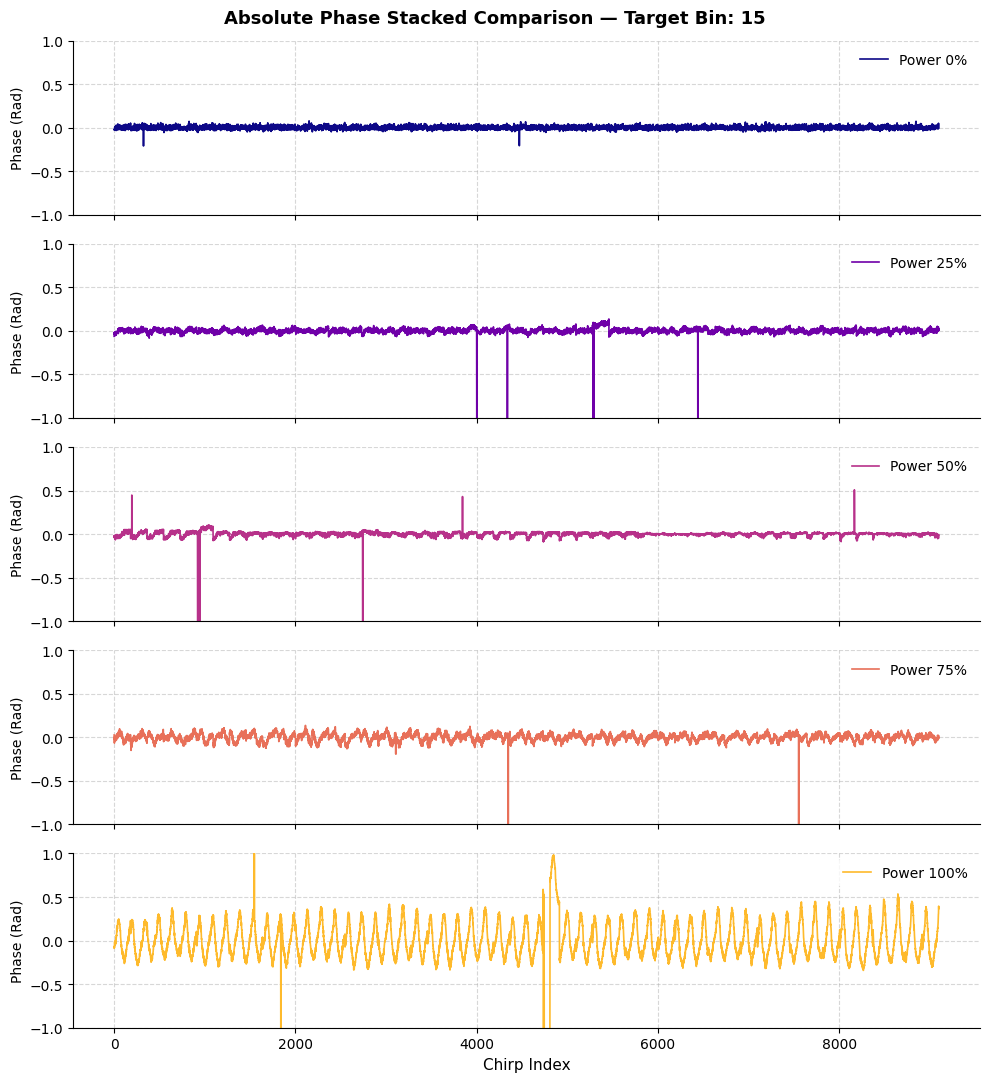

In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np

DATA_PATHS = [
    'data/Rock_vibration/depth_15/adc_data_2026-06-20_18-20-59_depth_15cm_motor_pow_0.npy',
    'data/Rock_vibration/depth_15/adc_data_2026-06-20_18-23-03_depth_15cm_motor_pow_25.npy',
    'data/Rock_vibration/depth_15/adc_data_2026-06-20_18-24-55_depth_15cm_motor_pow_50.npy',
    'data/Rock_vibration/depth_15/adc_data_2026-06-20_18-26-49_depth_15cm_motor_pow_75.npy',
    'data/Rock_vibration/depth_15/adc_data_2026-06-20_18-29-38_depth_15cm_motor_pow_100.npy'
]


start_frame = 100
num_frames = 50
selected_target_bin = 15 
labels = ["Power 0%", "Power 25%", "Power 50%", "Power 75%", "Power 100%"]
colors = plt.cm.plasma(np.linspace(0, 0.85, 5))

all_runs_phase_history = []

for path_idx, fp in enumerate(DATA_PATHS):
    file_path = f"../{fp}"  # Adapting your directory structure prefix
    print(f"\nProcessing File [{path_idx+1}/{len(DATA_PATHS)}]: {fp}")
    
    loaded_adc_data = np.load(file_path)
    absolute_phase_history = []

    for f in range(start_frame, start_frame + num_frames):
        current_frame = loaded_adc_data[f-1 : f]
        
        adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, 
                                       num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
        radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
        _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
        
        current_frame_phases = get_absolute_phases_for_frame(rangeResult, [selected_target_bin])
        absolute_phase_history.extend(current_frame_phases[selected_target_bin])
        
    all_runs_phase_history.append(absolute_phase_history)

print(f"\nGenerating Stacked Phase Plots for Bin {selected_target_bin}...")
fig, axes = plt.subplots(5, 1, figsize=(10, 11), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    chirp_indices = np.arange(len(all_runs_phase_history[i]))
    ax.plot(chirp_indices, all_runs_phase_history[i], color=colors[i], lw=1.2, label=labels[i])
    ax.set_ylim(-1, 1)
    ax.set_ylabel("Phase (Rad)", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel("Chirp Index", fontsize=11)
fig.suptitle(f"Absolute Phase Stacked Comparison — Target Bin: {selected_target_bin}", 
             fontsize=13, fontweight="bold", y=0.98)

plt.tight_layout()
os.makedirs(f"{save_dir}/Stacked_Results", exist_ok=True)
plt.savefig(f"{save_dir}/Stacked_Results/Stacked_Phase_Bin_{selected_target_bin}.png", dpi=300)
plt.show()

print("Stacked multi-file pipeline completed successfully.")

### Acceleration after filtering

In [ ]:
def paper_acceleration(d, dt):
    """ 
    Paper Eq.(2): [4d0 + (d1+d-1) - 2(d2+d-2) - (d3+d-3)] / 16·dt² 
    Calculates robust acceleration from displacement array.
    """
    acc = np.zeros_like(d)
    i = np.arange(3, len(d) - 3)
    # Vectorized calculation for extreme speed over the entire array
    acc[i] = (4*d[i] + (d[i+1] + d[i-1])
              - 2*(d[i+2] + d[i-2])
              -   (d[i+3] + d[i-3])) / (16 * dt**2)
    return acc

def plot_acceleration_from_filtered_phase(filtered_phase_history, absolute_phase_history, target_bins, lambda_m, dt, save_dir="Phase_Plots"):

    # Create distinct sub-directories for organization
    comp_folder = os.path.join(save_dir, "Phase_Comparisons")
    filtered_only_folder = os.path.join(save_dir, "Filtered_Phase_Only")
    
    os.makedirs(comp_folder, exist_ok=True)
    os.makedirs(filtered_only_folder, exist_ok=True)
    
    for target_bin in target_bins:
        # Extract both phase histories for the current range bin
        raw_phase = absolute_phase_history[target_bin]
        filtered_phase = filtered_phase_history[target_bin]
        
        # --- 1. Compute Raw Phase Acceleration ---
        disp_raw = (lambda_m / (4 * np.pi)) * raw_phase
        acc_raw = paper_acceleration(disp_raw, dt=dt)
        
        # --- 2. Compute Filtered Phase Acceleration ---
        disp_filtered = (lambda_m / (4 * np.pi)) * filtered_phase
        acc_filtered = paper_acceleration(disp_filtered, dt=dt)
        
        # Define a consistent time array
        time_axis = np.arange(len(acc_filtered)) * dt
        
        # =========================================================================
        # PLOT 1: Comparison between Raw Absolute Phase and Filtered Phase
        # =========================================================================
        plt.figure(figsize=(14, 7))
        plt.plot(time_axis, acc_raw, color='#7f7f7f', linewidth=1.0, alpha=0.5, label='Raw Unfiltered Phase Acceleration')
        plt.plot(time_axis, acc_filtered, color='#1f77b4', linewidth=1.3, alpha=0.9, label='Filtered Phase Acceleration')
        
        plt.title(f"Acceleration Comparison - Bin {target_bin}\nRaw Absolute vs. Dynamically Filtered Phase Profile", fontsize=14, fontweight='bold')
        plt.xlabel("Time (Seconds)", fontsize=12)
        plt.ylabel("Acceleration (m/s²)", fontsize=12)
        plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
        plt.tight_layout()
        
        comp_path = os.path.join(comp_folder, f"Accel_Bin_{target_bin}_comparison.png")
        plt.savefig(comp_path, dpi=300)
        plt.close()
        print(f"Saved Comparison plot for Bin {target_bin} -> {comp_path}")
        
        # =========================================================================
        # PLOT 2: Filtered Phase Acceleration Alone
        # =========================================================================
        plt.figure(figsize=(14, 6))
        plt.plot(time_axis, acc_filtered, color='#d62728', linewidth=1.2, alpha=0.9, label='Filtered Acceleration (m/s²)')
        
        plt.title(f"Target Acceleration - Bin {target_bin} (Paper Formula)\nCalculated from Pristine Dynamically Filtered Phase", fontsize=14, fontweight='bold')
        plt.xlabel("Time (Seconds)", fontsize=12)
        plt.ylabel("Acceleration (m/s²)", fontsize=12)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(loc='upper right')
        plt.tight_layout()
        
        filtered_path = os.path.join(filtered_only_folder, f"Accel_Bin_{target_bin}_filtered_phase_only.png")
        plt.savefig(filtered_path, dpi=300)
        plt.close()
        print(f"Saved Filtered Phase Only plot for Bin {target_bin} -> {filtered_path}")

In [ ]:

FREQ = 77e9                 
C = 3e8                     
LAMBDA_M = C / FREQ         
DT = 72e-6                  

# Calculate and plot acceleration from the filtered data
plot_acceleration_from_filtered_phase(
    filtered_phase_history=filtered_phase_history,
    absolute_phase_history=absolute_phase_history,
    target_bins=target_bins,
    lambda_m=LAMBDA_M,
    dt=DT,
    save_dir=save_dir,
)

# plot_acceleration_from_filtered_phase(
#     filtered_phase_history=absolute_phase_history,
#     target_bins=target_bins,
#     lambda_m=LAMBDA_M,
#     dt=DT,
#     save_dir=save_dir,
#     is_filtered_phase=False
# )

Saved Acceleration plot for Bin 12 -> ../Simulations/Radar/depth_10cm_motor_pow_75\Accelerations\Accel_Bin_12_filtered_phase.png
Saved Acceleration plot for Bin 13 -> ../Simulations/Radar/depth_10cm_motor_pow_75\Accelerations\Accel_Bin_13_filtered_phase.png
Saved Acceleration plot for Bin 14 -> ../Simulations/Radar/depth_10cm_motor_pow_75\Accelerations\Accel_Bin_14_filtered_phase.png
Saved Acceleration plot for Bin 15 -> ../Simulations/Radar/depth_10cm_motor_pow_75\Accelerations\Accel_Bin_15_filtered_phase.png
Saved Acceleration plot for Bin 16 -> ../Simulations/Radar/depth_10cm_motor_pow_75\Accelerations\Accel_Bin_16_filtered_phase.png
Saved Acceleration plot for Bin 17 -> ../Simulations/Radar/depth_10cm_motor_pow_75\Accelerations\Accel_Bin_17_filtered_phase.png
Saved Acceleration plot for Bin 18 -> ../Simulations/Radar/depth_10cm_motor_pow_75\Accelerations\Accel_Bin_18_filtered_phase.png
Saved Acceleration plot for Bin 12 -> ../Simulations/Radar/depth_10cm_motor_pow_75\Accelerations\

### Comparison plotting - Phase

In [76]:
unwrapped_phase_csv_paths_depth_5 = [
    "../Simulations\Radar\depth_5cm_motor_pow_0\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_5cm_motor_pow_25\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_5cm_motor_pow_50\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_5cm_motor_pow_75\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_5cm_motor_pow_100\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
]

unwrapped_phase_csv_paths_depth_10 = [
    "../Simulations\Radar\depth_10cm_motor_pow_0\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_10cm_motor_pow_25\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_10cm_motor_pow_50\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_10cm_motor_pow_75\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_10cm_motor_pow_100\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
]

unwrapped_phase_csv_paths_depth_15 = [
    "../Simulations\Radar\depth_15cm_motor_pow_0\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_15cm_motor_pow_25\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_15cm_motor_pow_50\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_15cm_motor_pow_75\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
    "../Simulations\Radar\depth_15cm_motor_pow_100\phase_CSV\Absolute_Phase_frames_100_to_150.csv",
]

filtered_phase_csv_paths_depth_5 = [
    "../Simulations/Radar/depth_5cm_motor_pow_0/CSV_Exports/Filtered_Phase_Export_20260623_073009.csv",
    "../Simulations/Radar/depth_5cm_motor_pow_25/CSV_Exports/Filtered_Phase_Export_20260623_073027.csv",
    "../Simulations/Radar/depth_5cm_motor_pow_50/CSV_Exports/Filtered_Phase_Export_20260623_072747.csv",
    "../Simulations/Radar/depth_5cm_motor_pow_75/CSV_Exports/Filtered_Phase_Export_20260623_072803.csv",
    "../Simulations/Radar/depth_5cm_motor_pow_100/CSV_Exports/Filtered_Phase_Export_20260623_072643.csv"
]

filtered_phase_csv_paths_depth_10 = [
    "../Simulations/Radar/depth_10cm_motor_pow_0/CSV_Exports/Filtered_Phase_Export_20260623_075108.csv",
    "../Simulations/Radar/depth_10cm_motor_pow_25/CSV_Exports/Filtered_Phase_Export_20260623_075124.csv",
    "../Simulations/Radar/depth_10cm_motor_pow_50/CSV_Exports/Filtered_Phase_Export_20260623_075138.csv",
    "../Simulations/Radar/depth_10cm_motor_pow_75/CSV_Exports/Filtered_Phase_Export_20260623_075154.csv",
    "../Simulations/Radar/depth_10cm_motor_pow_100/CSV_Exports/Filtered_Phase_Export_20260623_075211.csv"
]

filtered_phase_csv_paths_depth_15 = [
    "../Simulations/Radar/depth_15cm_motor_pow_0/CSV_Exports/Filtered_Phase_Export_20260623_074411.csv",
    "../Simulations/Radar/depth_15cm_motor_pow_25/CSV_Exports/Filtered_Phase_Export_20260623_074444.csv",
    "../Simulations/Radar/depth_15cm_motor_pow_50/CSV_Exports/Filtered_Phase_Export_20260623_074459.csv",
    "../Simulations/Radar/depth_15cm_motor_pow_75/CSV_Exports/Filtered_Phase_Export_20260623_074515.csv",
    "../Simulations/Radar/depth_15cm_motor_pow_100/CSV_Exports/Filtered_Phase_Export_20260623_074537.csv"
]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths and display labels
labels = ["Power 0%", "Power 25%", "Power 50%", "Power 75%", "Power 100%"]

data_list = [pd.read_csv(p)["Bin_15"] for p in unwrapped_phase_csv_paths_depth_15]
colors = plt.cm.plasma(np.linspace(0, 0.85, 5))  # Professional color palette

fig, axes = plt.subplots(5, 1, figsize=(10, 11), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    ax.plot(data_list[i], color=colors[i], lw=1.2, label=labels[i])
    ax.set_ylim(-0.5, 0.5)
    ax.set_ylabel("Phase", fontsize=10, fontweight="medium")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel("Time / Sample Index", fontsize=11, fontweight="medium")
fig.suptitle("Filtered Phase Comparison (Bin 15) — Stacked", fontsize=13, fontweight="bold", y=0.98)

plt.tight_layout()
plt.savefig("../Simulations/Radar/depth_15_Comparison/stacked_phase_comparison.png", dpi=300)
plt.show()


### Comparison plotting - Acceleration

In [41]:
filtered_accelerations_csv_paths_depth_5 = [
    "../Simulations\Radar\depth_5cm_motor_pow_0\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_5cm_motor_pow_25\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_5cm_motor_pow_50\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_5cm_motor_pow_75\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_5cm_motor_pow_100\Accel_CSV\Accel_Bin_15_filtered_phase.csv"
]

filtered_accelerations_csv_paths_depth_10 = [
    "../Simulations\Radar\depth_10cm_motor_pow_0\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_10cm_motor_pow_25\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_10cm_motor_pow_50\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_10cm_motor_pow_75\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_10cm_motor_pow_100\Accel_CSV\Accel_Bin_15_filtered_phase.csv"
]
filtered_accelerations_csv_paths_depth_15 = [
    "../Simulations\Radar\depth_15cm_motor_pow_0\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_15cm_motor_pow_25\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_15cm_motor_pow_50\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_15cm_motor_pow_75\Accel_CSV\Accel_Bin_15_filtered_phase.csv",
    "../Simulations\Radar\depth_15cm_motor_pow_100\Accel_CSV\Accel_Bin_15_filtered_phase.csv"
]

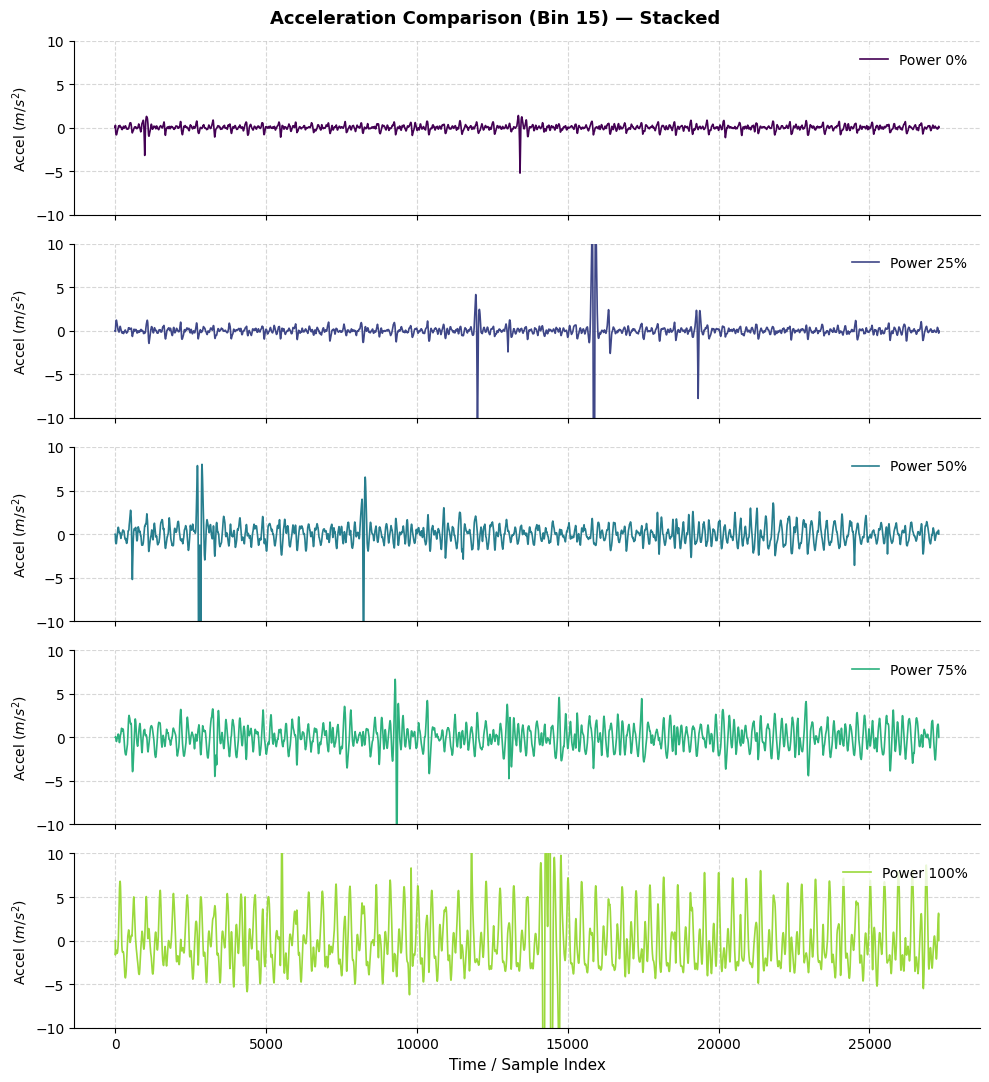

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths and display labels
paths = filtered_accelerations_csv_paths_depth_15
labels = ["Power 0%", "Power 25%", "Power 50%", "Power 75%", "Power 100%"]
target_column = "Acceleration (m/s2)"

# Load data
data_list = [pd.read_csv(p)[target_column] for p in paths]
colors = plt.cm.viridis(np.linspace(0, 0.85, 5))  # Clean, professional color palette


fig, axes = plt.subplots(5, 1, figsize=(10, 11), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    ax.plot(data_list[i], color=colors[i], lw=1.2, label=labels[i])
    ax.set_ylim(-10, 10) # Uncomment if you want to force a strict baseline comparison
    ax.set_ylabel(r"Accel ($m/s^2$)", fontsize=10, fontweight="medium")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel("Time / Sample Index", fontsize=11, fontweight="medium")
fig.suptitle("Acceleration Comparison (Bin 15) — Stacked", fontsize=13, fontweight="bold", y=0.98)

plt.tight_layout()
plt.savefig("../Simulations/Radar/depth_15_Comparison/stacked_acceleration_comparison.png", dpi=300)
plt.show()

# # ----------------------------------------------------
# # 2. OVERLAPPING PLOT (All lines on a single plot)
# # ----------------------------------------------------
# plt.figure(figsize=(10, 5.5))

# for i, data in enumerate(data_list):
#     plt.plot(data, color=colors[i], lw=1.2, alpha=0.85, label=labels[i])

# plt.xlabel("Time / Sample Index", fontsize=11, fontweight="medium")
# plt.ylabel(r"Acceleration ($m/s^2$)", fontsize=11, fontweight="medium")
# plt.title("Acceleration Comparison (Bin 15) — Overlapping", fontsize=13, fontweight="bold", pad=15)
# plt.ylim(-4,4)
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.legend(loc="upper right", frameon=True, shadow=False)

# ax = plt.gca()
# for spine in ["top", "right"]:
#     ax.spines[spine].set_visible(False)

# plt.tight_layout()
# plt.savefig("../Simulations/Radar/depth_15_Comparison/overlapping_acceleration_comparison.png", dpi=300)
# plt.show()

In [ ]:
from matplotlib import offsetbox
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

# --- CORRECTED PATH ARRAYS ---
unwrapped_phase_csv_paths_depth_5 = [
    "../Simulations/Radar/depth_5cm_motor_pow_0/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_5cm_motor_pow_25/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_5cm_motor_pow_50/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_5cm_motor_pow_75/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_5cm_motor_pow_100/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
]

unwrapped_phase_csv_paths_depth_10 = [
    "../Simulations/Radar/depth_10cm_motor_pow_0/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_10cm_motor_pow_25/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_10cm_motor_pow_50/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_10cm_motor_pow_75/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_10cm_motor_pow_100/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
]

unwrapped_phase_csv_paths_depth_15 = [
    "../Simulations/Radar/depth_15cm_motor_pow_0/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_15cm_motor_pow_25/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_15cm_motor_pow_50/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_15cm_motor_pow_75/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
    "../Simulations/Radar/depth_15cm_motor_pow_100/phase_CSV/Absolute_Phase_frames_100_to_150.csv",
]

# --- DSP CONFIGURATION ---
target_bin = 15
Tloop = 21e-5
lambda_m = 0.004
FILTER_LO = 20.0
FILTER_HI = 100.0
fs_slow = 1 / Tloop
labels = ["Power 0%", "Power 25%", "Power 50%", "Power 75%", "Power 100%"]
colors = plt.cm.plasma(np.linspace(0, 0.85, 5))

def bandpass_filter(sig, fs=fs_slow, lowcut=FILTER_LO, highcut=FILTER_HI, order=5, Tc = 72e-6):
    Fs = 1.0 / Tc
    nyq = 0.5 * Fs 
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')
    filtered_data = sosfiltfilt(sos, data) 
    return filtered_data
    
    return filtered_data

def paper_acceleration(d, dt):
    """Paper Eq.(2): [4d0 + (d1+d-1) - 2(d2+d-2) - (d3+d-3)] / 16·dt²"""
    acc = np.zeros_like(d)
    i = np.arange(3, len(d) - 3)
    acc[i] = (
        4 * d[i]
        + (d[i + 1] + d[i - 1])
        - 2 * d[i + 2]
        - 2 * d[i - 2]
        - d[i + 3]
        - d[i - 3]
    ) / (16 * dt**2)
    return acc

# --- BATCH PROCESSING & PLOTTING ---
all_depth_groups = {
    "5cm": unwrapped_phase_csv_paths_depth_5,
    "10cm": unwrapped_phase_csv_paths_depth_10,
    "15cm": unwrapped_phase_csv_paths_depth_15,
}

for depth_label, paths in all_depth_groups.items():
    print(f"Processing depth: {depth_label}...")

    # Calculate accelerations for all 5 power levels in the group
    accel_dataset = []
    for path in paths:
        df = pd.read_csv(path)
        raw_phase = df[f"Bin_{target_bin}"].to_numpy()

        disp = (lambda_m / (4 * np.pi)) * raw_phase
        filtered_disp = bandpass_filter(disp)
        accel = paper_acceleration(filtered_disp, dt=Tloop)
        accel_dataset.append(accel)

    # Generate stacked plot (5 subplots)
    fig, axes = plt.subplots(5, 1, figsize=(10, 11), sharex=True, sharey=True)
    time_axis = np.arange(len(accel_dataset[0])) * Tloop

    for i, ax in enumerate(axes):
        ax.plot(time_axis, accel_dataset[i], color=colors[i], lw=1.2, label=labels[i])
        ax.set_ylabel(r"Accel ($m/s^2$)", fontsize=10, fontweight="medium")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.set_ylim(-10,10)
        ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    axes[-1].set_xlabel("Time (Seconds)", fontsize=11, fontweight="medium")
    fig.suptitle(
        f"Calculated Acceleration Comparison (Bin {target_bin}) — Depth: {depth_label}",
        fontsize=13,
        fontweight="bold",
        y=0.98,
    )

    plt.tight_layout()
    plt.savefig(f"stacked_acceleration_depth_{depth_label}.png", dpi=300)
    plt.close()

print("All stacked depth plots generated and saved successfully.")

Processing depth: 5cm...
Processing depth: 10cm...
Processing depth: 15cm...
All stacked depth plots generated and saved successfully.
